# ***Task 4: Predicting Insurance Claim Amounts***

## Overview

In this task, we use the Medical Cost Personal Dataset to predict insurance charges based on personal attributes such as age, BMI, smoking status, and region. We perform exploratory data analysis to uncover key patterns, then train a Linear Regression model to estimate claim amounts. Model performance is evaluated using MAE and RMSE metrics.

##Step 1 — Setup & Data Loading

Import all necessary libraries first, then load the dataset to understand its structure, data types, and basic statistics.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error



In [5]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


##Step 2 — Exploratory Data Analysis (EDA)

Visualize key features to understand how age, BMI, and smoking status influence insurance charges.

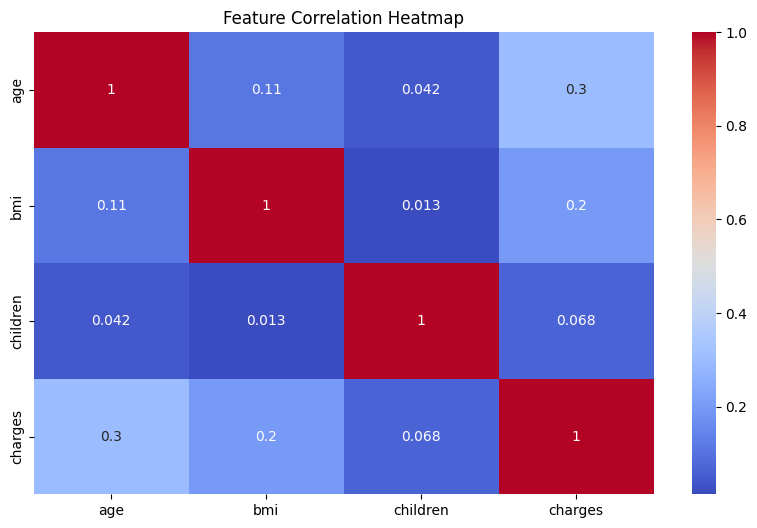

In [8]:
# Heatmap - feature correlations
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

/tmp/ipykernel_247/2786740257.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')


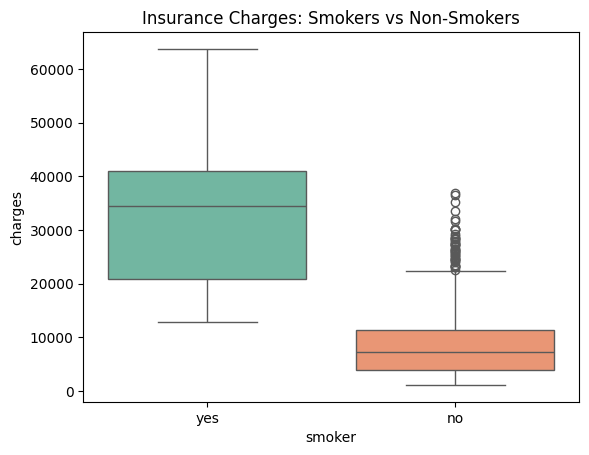

In [9]:
# Smoker vs Non-Smoker charges comparison (unique insight!)
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')
plt.title("Insurance Charges: Smokers vs Non-Smokers")
plt.show()

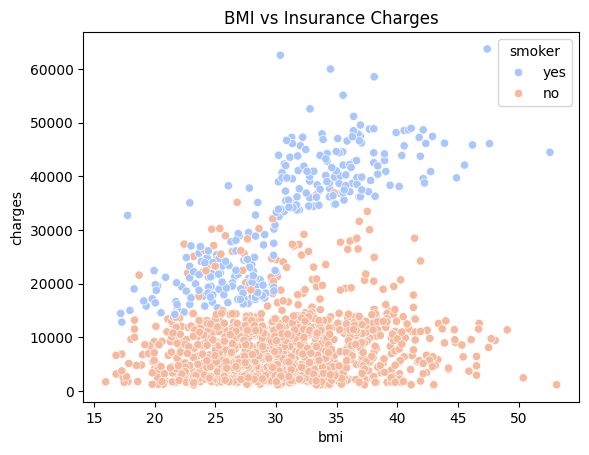

In [10]:
# BMI vs Charges scatter with smoking color
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, palette='coolwarm')
plt.title("BMI vs Insurance Charges")
plt.show()

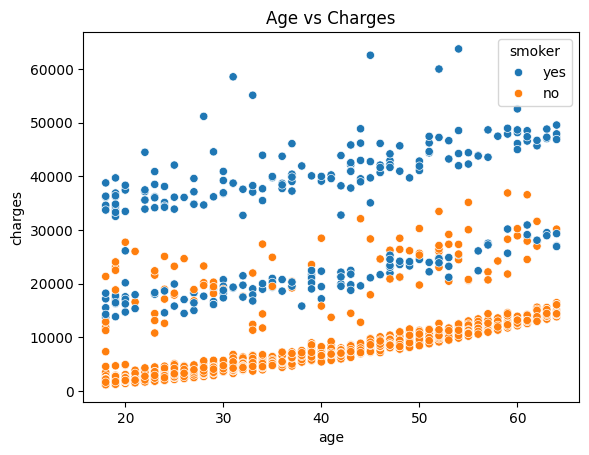

In [11]:
# Age vs Charges
sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title("Age vs Charges")
plt.show()

##Step 3 — Data Preprocessing

Machine learning models require numerical input. Convert categorical columns (sex, smoker, region) into numeric format using one-hot encoding.

In [13]:
# Encode categorical columns
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##Step 4 — Model Training

Train a Linear Regression model, which finds the best-fit line to predict insurance charges based on input features.

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

##Step 5 — Model Evaluation

Measure model performance using MAE and RMSE. Lower values indicate better accuracy. Visualize actual vs predicted values to assess overall fit.

MAE: 4181.19
RMSE: 5796.28


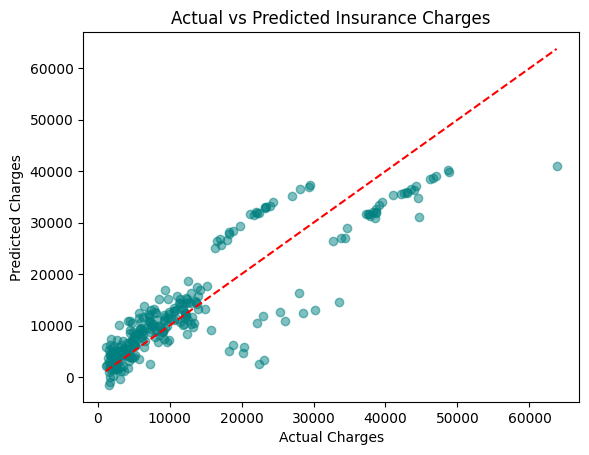

In [15]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# Actual vs Predicted plot (unique touch!)
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.show()